## Load data

In [ ]:
!pip install scikit-multilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 2.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import torch
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from skmultilearn.model_selection.measures import get_combination_wise_output_matrix
from collections import Counter
import os

In [ ]:
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')

Mounted at /content/gdrive


In [ ]:
df = pd.read_csv("/content/gdrive/My Drive/MSc Project/fabsa.csv", converters={'labels': ast.literal_eval})
train_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_df.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

## Dataset Exploration

In [ ]:
df.head()

,id,text,labels,org_index,industry,data_source
0,301988849,Literally only place I get my shoes,[company-brand.general-satisfaction.1],727,Fashion,Google Play
1,301988545,Will not let me login,[account-management.account-access.-1],727,Fashion,Google Play
2,576785371,"I've already reviewed it, so please let me sig...",[account-management.account-access.0],5827,Consulting,Apple Store
3,301983983,Easy to use and price is good,"[purchase-booking-experience.ease-of-use.1, va...",549,Travel Booking,Google Play
4,301988330,I find this app easy to use and with an extens...,"[purchase-booking-experience.ease-of-use.1, on...",727,Fashion,Google Play


In [ ]:
len(df)

10574

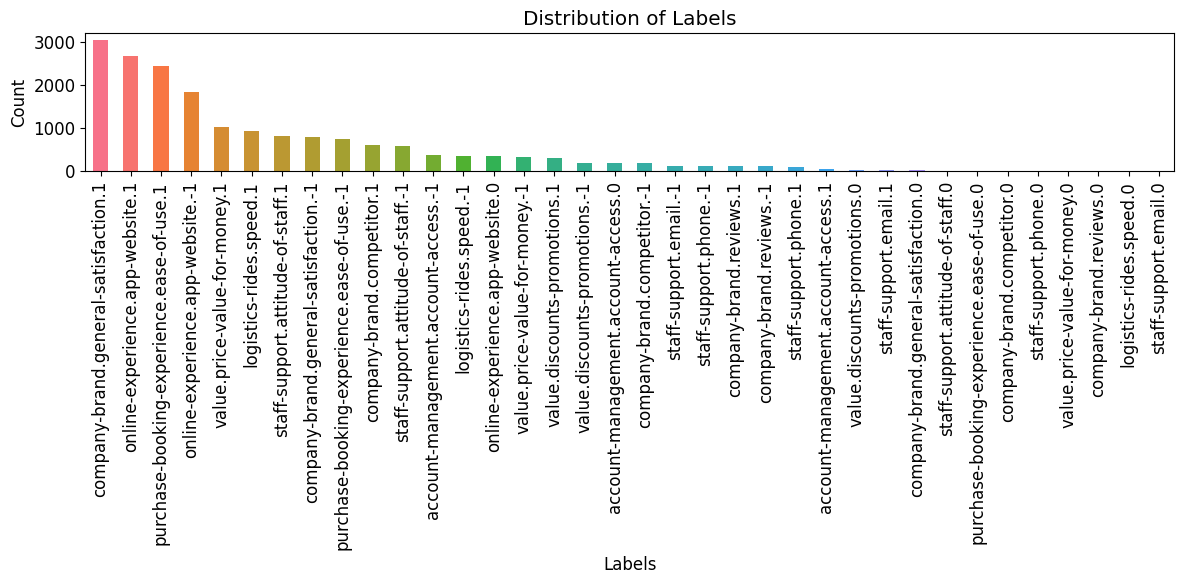

In [ ]:
# Function to extract individual labels from the list
def extract_labels(label_str):
    labels_list = ast.literal_eval(label_str)
    return labels_list

# Apply the function to extract individual labels and store them in a list
all_labels = df['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Plot the distribution of labels
plt.figure(figsize=(12, 6))

# Use a colorful palette from seaborn for the bars
palette = sns.color_palette("husl", len(label_counts))

label_counts.plot(kind='bar', color=palette)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


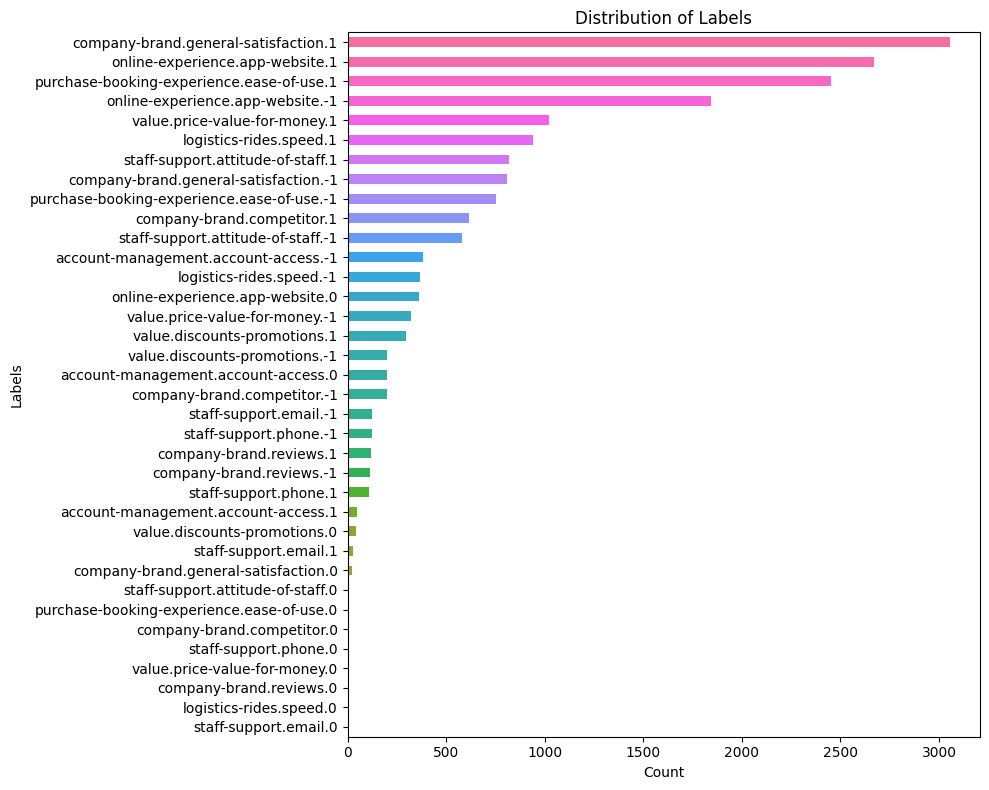

staff-support.email                         155
company-brand.reviews                       237
staff-support.phone                         238
value.discounts-promotions                  542
account-management.account-access           633
company-brand.competitor                    823
logistics-rides.speed                      1310
value.price-value-for-money                1349
staff-support.attitude-of-staff            1407
purchase-booking-experience.ease-of-use    3214
company-brand.general-satisfaction         3886
online-experience.app-website              4874
Name: category, dtype: int64


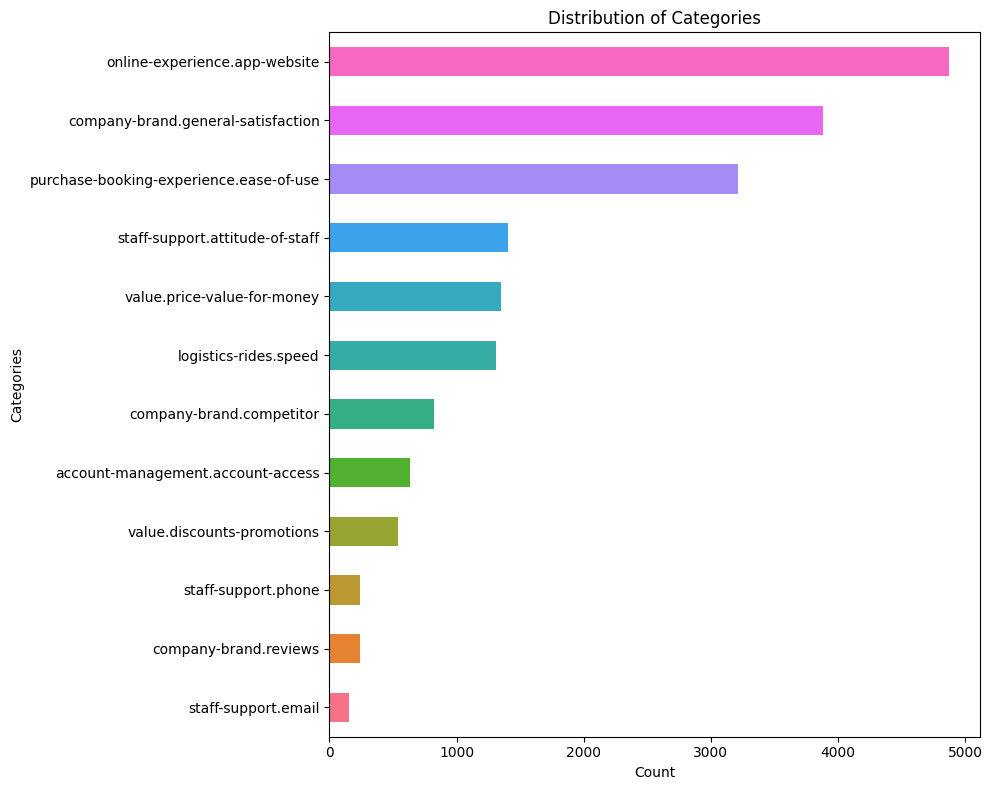

In [ ]:
# Apply the function to extract individual labels and store them in a list
all_labels = df['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts().sort_values()

# Plot the distribution of labels
plt.figure(figsize=(10, 8))

# Use a colorful palette from seaborn for the bars
palette = sns.color_palette("husl", len(label_counts))

# Set the font size for axis labels, title, and ticks
plt.rcParams.update({'font.size': 10})

label_counts.plot(kind='barh', color=palette)
plt.ylabel('Labels')
plt.xlabel('Count')
plt.title('Distribution of Labels')
plt.tight_layout()
plt.show()

# Create a separate DataFrame for the categories
df_categories = pd.DataFrame({'category': df['labels'].apply(lambda x: [i.rsplit('.', 1)[0] for i in x]).explode()})

# Count the occurrences of each category
category_counts = df_categories['category'].value_counts().sort_values()

# Set a color palette
palette = sns.color_palette("husl", len(category_counts))

# Print the counts
print(category_counts)

# Plot the distribution of categories
plt.figure(figsize=(10, 8))
category_counts.plot(kind='barh', color=palette)
plt.ylabel('Categories')
plt.xlabel('Count')
plt.title('Distribution of Categories')
plt.tight_layout()
plt.show()


In [ ]:
# Print the number of labels
num_labels = len(label_counts)
print(f"Number of Total Labels: {num_labels}")

# Count the occurrences of labels ending with '.1', '.-1', and '.0'
labels_ending_dot_1 = label_counts.index[label_counts.index.str.endswith('.1')]
labels_ending_dot_minus_1 = label_counts.index[label_counts.index.str.endswith('.-1')]
labels_ending_dot_0 = label_counts.index[label_counts.index.str.endswith('.0')]

# Print the counts of labels ending with '.1', '.-1', and '.0'
print(f"Number of positive labels: {len(labels_ending_dot_1)}")
print(f"Number of negative labels: {len(labels_ending_dot_minus_1)}")
print(f"Number of neutral labels: {len(labels_ending_dot_0)}")

Number of Total Labels: 36
Number of positive labels: 12
Number of negative labels: 12
Number of neutral labels: 12


Sum of positive labels: 12173
Sum of negative labels: 5828
Sum of neutral labels: 667


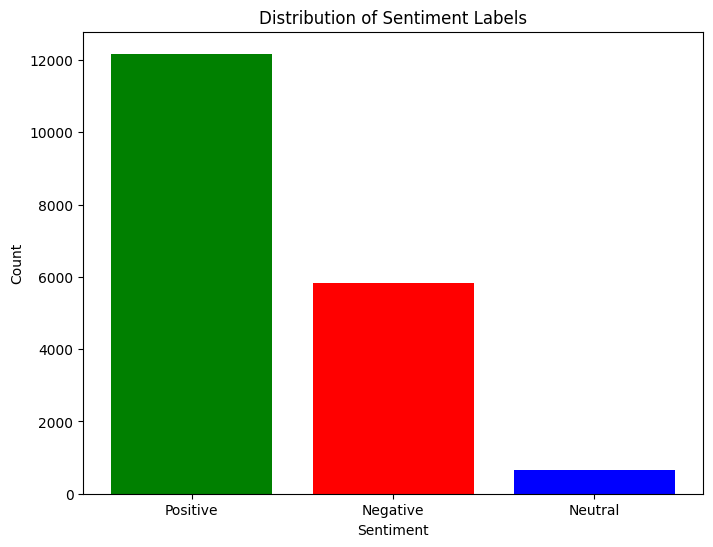

In [ ]:
# Count the sum of positive, negative, and neutral labels
count_positive_labels = sum([label_counts[i] for i in label_counts.index if i.endswith('.1')])
count_negative_labels = sum([label_counts[i] for i in label_counts.index if i.endswith('.-1')])
count_neutral_labels = sum([label_counts[i] for i in label_counts.index if i.endswith('.0')])

# Print the sums
print(f"Sum of positive labels: {count_positive_labels}")
print(f"Sum of negative labels: {count_negative_labels}")
print(f"Sum of neutral labels: {count_neutral_labels}")


# Plot the sums
plt.figure(figsize=(8, 6))
plt.bar(['Positive', 'Negative', 'Neutral'], [count_positive_labels, count_negative_labels, count_neutral_labels], color=['g', 'r', 'b'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Labels')
plt.show()

In [ ]:
# Create a separate DataFrame for the categories
def parse_labels(x):
    if isinstance(x, str):
        return [i.rsplit('.', 1)[0] for i in ast.literal_eval(x)]
    elif isinstance(x, list):
        return [i.rsplit('.', 1)[0] for i in x]
    else:
        return []

df_categories = pd.DataFrame({'category': df['labels'].apply(parse_labels).explode()})

# Count the occurrences of each category
category_counts = df_categories['category'].value_counts()

# Print the counts
print(category_counts)

# Plot the distribution of categories
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Distribution of Categories')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


online-experience.app-website              4874
company-brand.general-satisfaction         3886
purchase-booking-experience.ease-of-use    3214
staff-support.attitude-of-staff            1407
value.price-value-for-money                1349
logistics-rides.speed                      1310
company-brand.competitor                    823
account-management.account-access           633
value.discounts-promotions                  542
staff-support.phone                         238
company-brand.reviews                       237
staff-support.email                         155
Name: category, dtype: int64


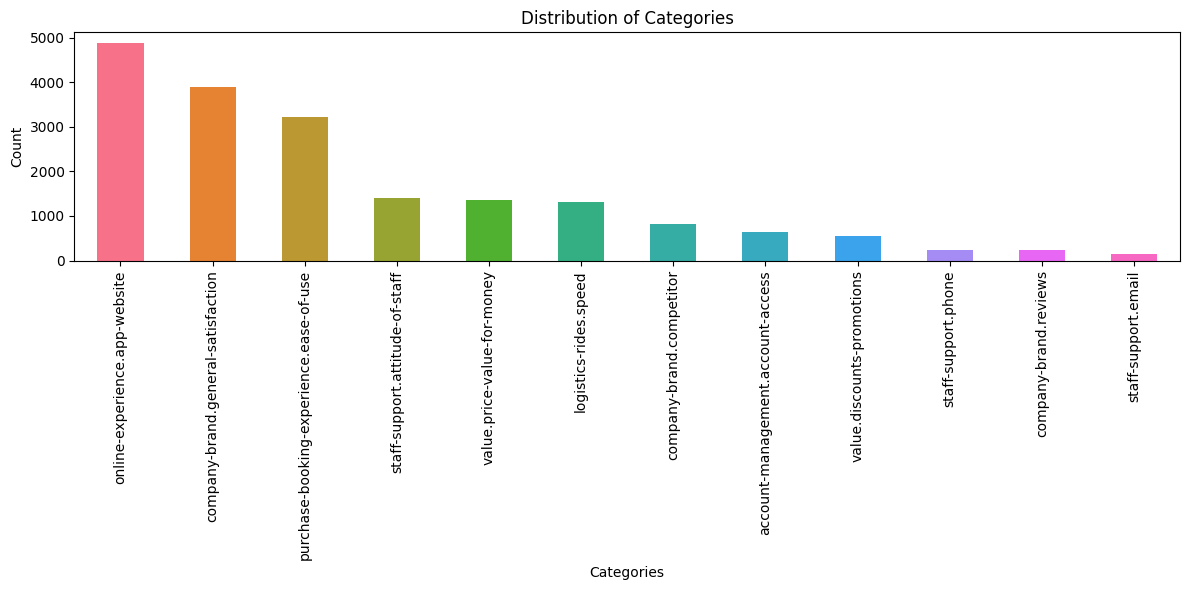

In [ ]:
# Create a separate DataFrame for the categories
df_categories = pd.DataFrame({'category': df['labels'].apply(lambda x: [i.rsplit('.', 1)[0] for i in x]).explode()})

# Count the occurrences of each category
category_counts = df_categories['category'].value_counts()

# Set a color palette
palette = sns.color_palette("husl", len(category_counts))

# Print the counts
print(category_counts)

# Plot the distribution of categories
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color=palette)
plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Distribution of Categories')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Average label count: 1.7654624550784945


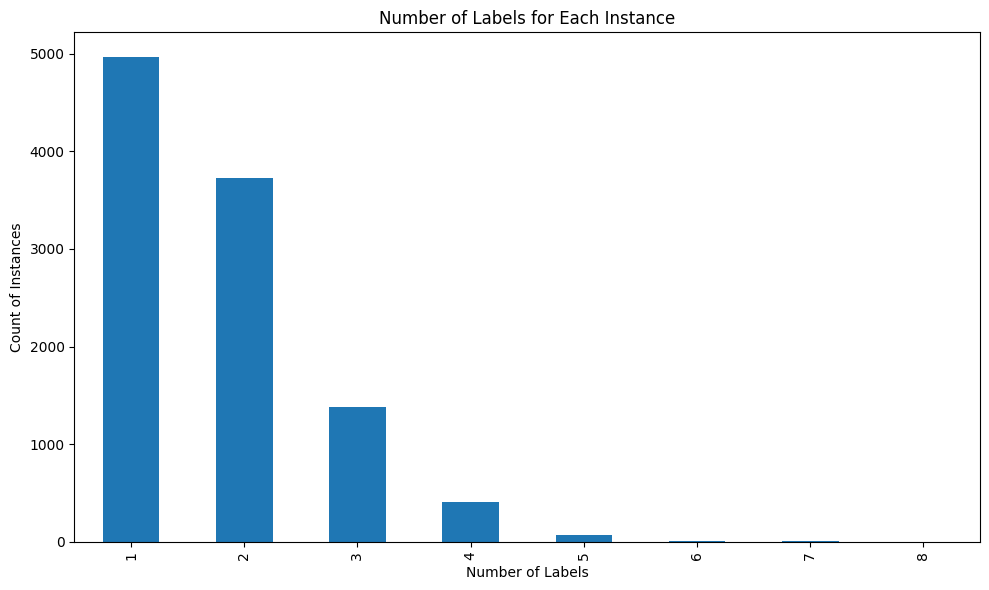

In [ ]:
# Function to extract individual labels from the list and count the number of labels for each entry
def count_labels(label_str):
    labels_list = ast.literal_eval(label_str)
    return len(labels_list)

# Apply the function to count the number of labels for each entry
df['label_count'] = df['labels'].apply(count_labels)

# Calculate and print the average label count
average_label_count = df['label_count'].mean()
print(f"Average label count: {average_label_count}")

# Plot the distribution of label counts
plt.figure(figsize=(10, 6))
df['label_count'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of Labels')
plt.ylabel('Count of Instances')
plt.title('Number of Labels for Each Instance')
plt.tight_layout()
plt.show()

## Split the dataset into train and validation

In [ ]:
# Define the file path
file_path = "/content/gdrive/My Drive/MSc Project/"

# Split the dataframe into train and validation
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)

# Save train_df and val_df to CSV files
train_df.to_csv(os.path.join(file_path, "train_df.csv"), index=False)
val_df.to_csv(os.path.join(file_path, "val_df.csv"), index=False)

## Sampling train dataset

Total data distribution


Label Counts:
 company-brand.general-satisfaction.1          3055
online-experience.app-website.1               2670
purchase-booking-experience.ease-of-use.1     2451
online-experience.app-website.-1              1842
value.price-value-for-money.1                 1022
logistics-rides.speed.1                        941
staff-support.attitude-of-staff.1              817
company-brand.general-satisfaction.-1          808
purchase-booking-experience.ease-of-use.-1     754
company-brand.competitor.1                     615
staff-support.attitude-of-staff.-1             580
account-management.account-access.-1           385
logistics-rides.speed.-1                       367
online-experience.app-website.0                362
value.price-value-for-money.-1                 323
value.discounts-promotions.1                   299
value.discounts-promotions.-1                  202
account-management.account-access.0            202
company-brand.competitor.-1                    202
staff-support.e

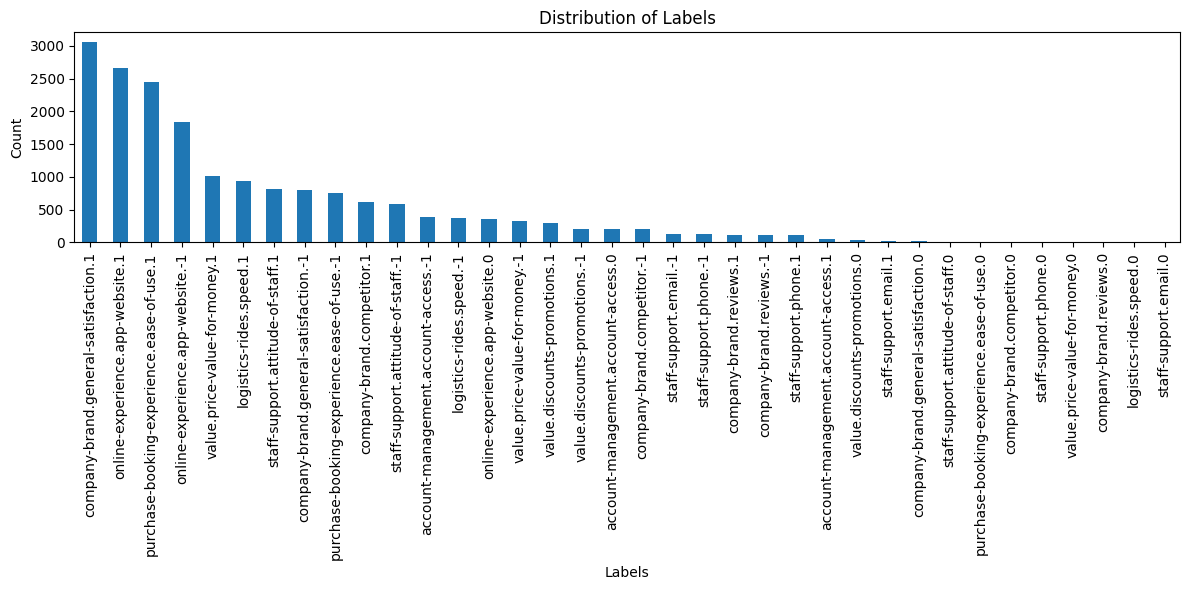

In [ ]:
# Apply the function to extract individual labels and store them in a list
all_labels = df['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of labels
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Train data set distribution


Label Counts:
 company-brand.general-satisfaction.1          2143
online-experience.app-website.1               1892
purchase-booking-experience.ease-of-use.1     1717
online-experience.app-website.-1              1303
value.price-value-for-money.1                  703
logistics-rides.speed.1                        653
staff-support.attitude-of-staff.1              575
company-brand.general-satisfaction.-1          547
purchase-booking-experience.ease-of-use.-1     538
company-brand.competitor.1                     438
staff-support.attitude-of-staff.-1             406
account-management.account-access.-1           264
online-experience.app-website.0                249
logistics-rides.speed.-1                       236
value.price-value-for-money.-1                 226
value.discounts-promotions.1                   207
value.discounts-promotions.-1                  151
account-management.account-access.0            147
company-brand.competitor.-1                    136
company-brand.r

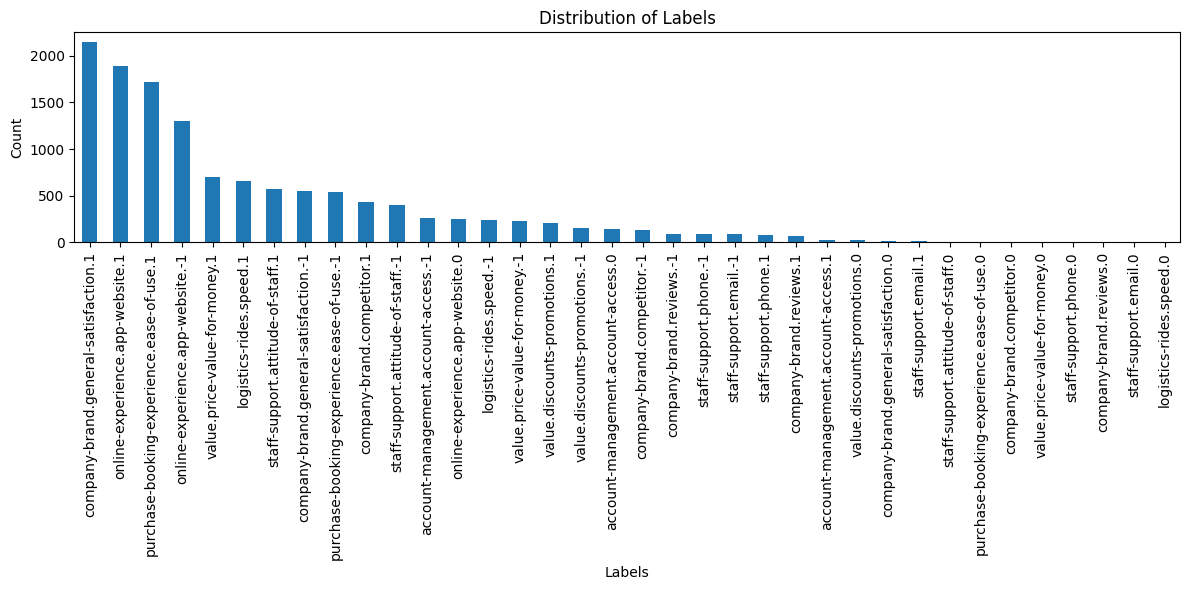

In [ ]:
# Apply the function to extract individual labels and store them in a list
all_labels = train_df['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of label
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
len(train_df)

7404

Validation set distribution


Label Counts:
 company-brand.general-satisfaction.1          912
online-experience.app-website.1               778
purchase-booking-experience.ease-of-use.1     734
online-experience.app-website.-1              539
value.price-value-for-money.1                 319
logistics-rides.speed.1                       288
company-brand.general-satisfaction.-1         261
staff-support.attitude-of-staff.1             242
purchase-booking-experience.ease-of-use.-1    216
company-brand.competitor.1                    177
staff-support.attitude-of-staff.-1            174
logistics-rides.speed.-1                      131
account-management.account-access.-1          121
online-experience.app-website.0               113
value.price-value-for-money.-1                 97
value.discounts-promotions.1                   92
company-brand.competitor.-1                    66
account-management.account-access.0            55
value.discounts-promotions.-1                  51
company-brand.reviews.1           

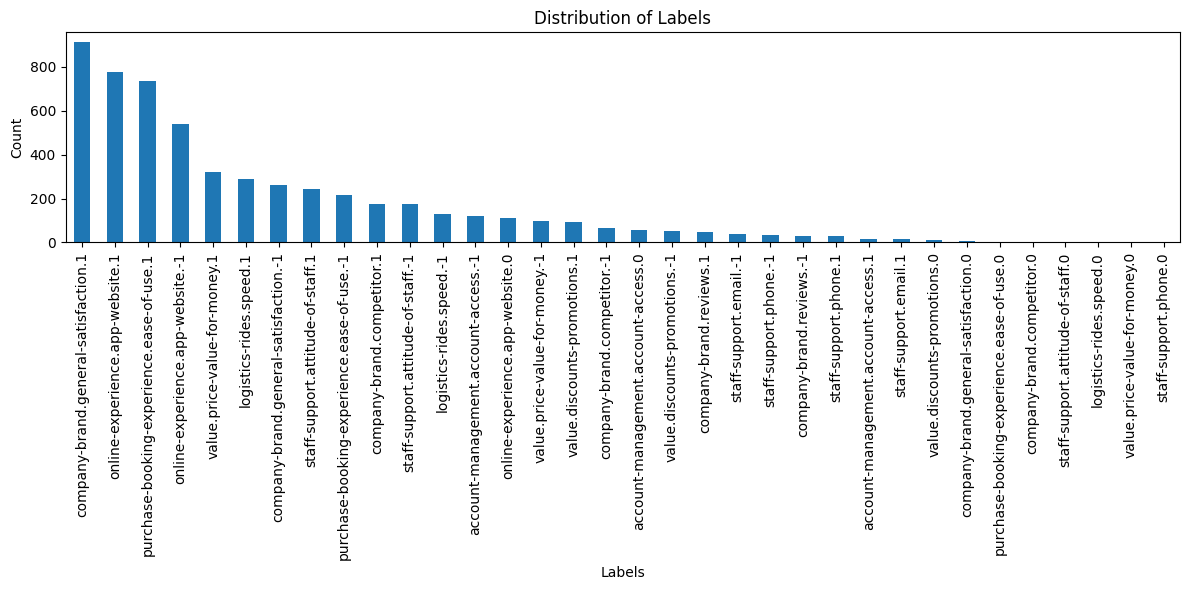

In [ ]:
# Apply the function to extract individual labels and store them in a list
all_labels = val_df['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of label
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1% Subsample

In [ ]:
# Convert 'labels' column to a format compatible with skmultilearn
label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
y = label_dummies.values
X = train_df.drop('labels', axis=1).values

# Use iterative stratification to get a subset
X_subset, y_subset, _, _ = iterative_train_test_split(X, y, test_size=0.99)

# Convert y_subset back to your original format
def get_original_labels(row, label_mapping):
    return [label_mapping[i] for i, x in enumerate(row) if x == 1]

label_mapping = label_dummies.columns
labels_subset = pd.DataFrame(y_subset).apply(lambda row: get_original_labels(row, label_mapping), axis=1)

# Check if all labels are present in the subset
missing_labels = set(label_mapping) - set(labels_subset.explode().unique())

# Add instances for missing labels
for missing_label in missing_labels:
    missing_label_index = label_dummies[label_dummies[missing_label] == 1].index[0]
    X_subset = np.vstack([X_subset, X[missing_label_index]])
    y_subset = np.vstack([y_subset, y[missing_label_index]])

    # Update labels_subset
    row_labels = get_original_labels(y[missing_label_index], label_mapping)
    labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)

# Create a DataFrame for the subset
train_subset = pd.DataFrame(X_subset, columns=train_df.columns.drop('labels'))
train_subset['labels'] = labels_subset

# Check the distribution of label combinations
combinations = Counter(str(combination) for row in get_combination_wise_output_matrix(y_subset, order=2) for combination in row)

<ipython-input-31-4c8ed77c56a9>:2: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
<ipython-input-31-4c8ed77c56a9>:27: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)


In [ ]:
train_subset.to_csv('/content/gdrive/My Drive/MSc Project/train_subset.csv', index=False)

In [ ]:
len(train_subset)

88


Label Counts:
 company-brand.general-satisfaction.1          23
online-experience.app-website.1               22
purchase-booking-experience.ease-of-use.1     20
online-experience.app-website.-1              15
value.price-value-for-money.1                 11
logistics-rides.speed.1                        8
staff-support.attitude-of-staff.1              7
company-brand.general-satisfaction.-1          6
purchase-booking-experience.ease-of-use.-1     6
account-management.account-access.-1           5
company-brand.competitor.1                     5
staff-support.attitude-of-staff.-1             5
logistics-rides.speed.-1                       4
value.discounts-promotions.-1                  3
company-brand.competitor.-1                    3
value.discounts-promotions.1                   2
online-experience.app-website.0                2
value.price-value-for-money.-1                 2
company-brand.reviews.-1                       2
company-brand.general-satisfaction.0           2
staf

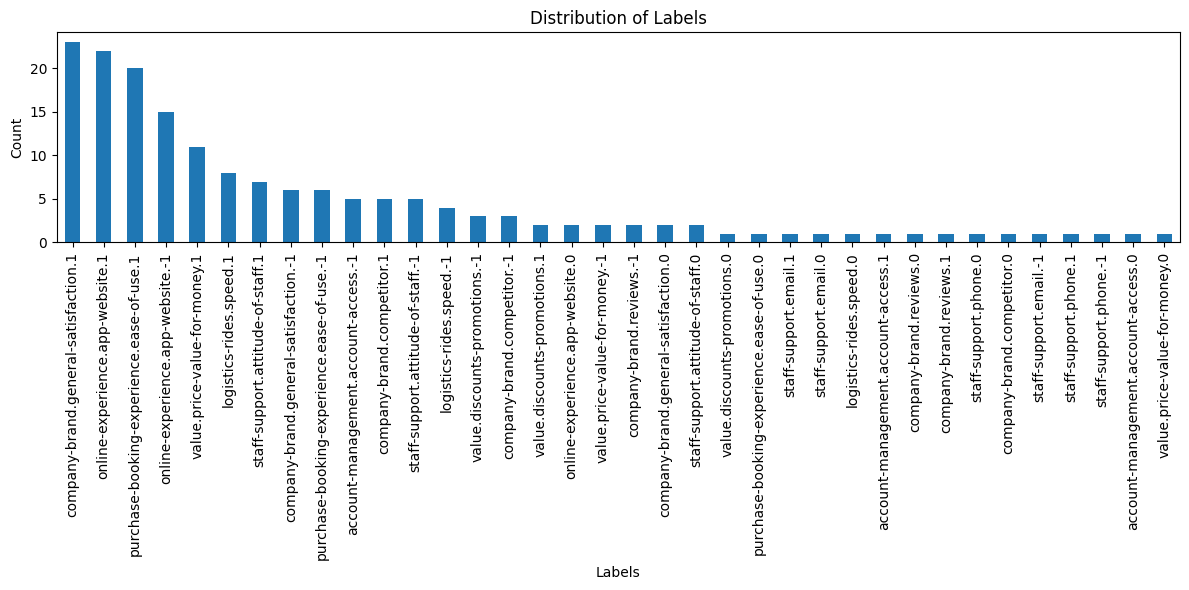

In [ ]:
# Apply the function to extract individual labels and store them in a list
all_labels = train_subset['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of labels
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

5% Subsample

In [ ]:
# Convert 'labels' column to a format compatible with skmultilearn
label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
y = label_dummies.values
X = train_df.drop('labels', axis=1).values

# Use iterative stratification to get a subset
X_subset, y_subset, _, _ = iterative_train_test_split(X, y, test_size=0.95)

# Convert y_subset back to your original format
def get_original_labels(row, label_mapping):
    return [label_mapping[i] for i, x in enumerate(row) if x == 1]

label_mapping = label_dummies.columns
labels_subset = pd.DataFrame(y_subset).apply(lambda row: get_original_labels(row, label_mapping), axis=1)

# Check if all labels are present in the subset
missing_labels = set(label_mapping) - set(labels_subset.explode().unique())

# Add instances for missing labels
for missing_label in missing_labels:
    missing_label_index = label_dummies[label_dummies[missing_label] == 1].index[0]
    X_subset = np.vstack([X_subset, X[missing_label_index]])
    y_subset = np.vstack([y_subset, y[missing_label_index]])

    # Update labels_subset
    row_labels = get_original_labels(y[missing_label_index], label_mapping)
    labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)

# Create a DataFrame for the subset
train_subset = pd.DataFrame(X_subset, columns=train_df.columns.drop('labels'))
train_subset['labels'] = labels_subset

# Check the distribution of label combinations
combinations = Counter(str(combination) for row in get_combination_wise_output_matrix(y_subset, order=2) for combination in row)

<ipython-input-19-9258355fe6e7>:6: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
<ipython-input-19-9258355fe6e7>:31: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)


In [ ]:
train_subset.to_csv('/content/gdrive/My Drive/MSc Project/train_subset5.csv', index=False)


Label Counts:
 company-brand.general-satisfaction.1          109
online-experience.app-website.1                98
purchase-booking-experience.ease-of-use.1      88
online-experience.app-website.-1               67
value.price-value-for-money.1                  41
logistics-rides.speed.1                        34
staff-support.attitude-of-staff.1              30
company-brand.general-satisfaction.-1          28
purchase-booking-experience.ease-of-use.-1     28
company-brand.competitor.1                     26
staff-support.attitude-of-staff.-1             24
account-management.account-access.-1           16
logistics-rides.speed.-1                       14
online-experience.app-website.0                12
value.price-value-for-money.-1                 12
value.discounts-promotions.1                   12
company-brand.competitor.-1                    11
value.discounts-promotions.-1                   9
account-management.account-access.0             7
staff-support.phone.-1            

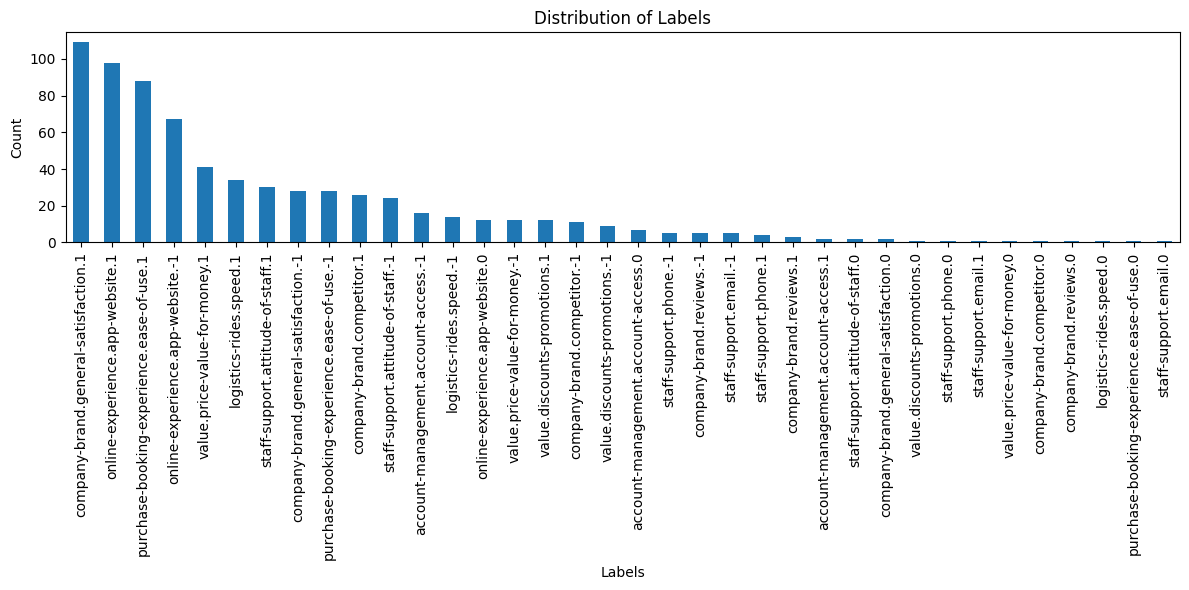

In [ ]:
train_subset05 = pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset5.csv', converters={'labels': ast.literal_eval})

# Apply the function to extract individual labels and store them in a list
all_labels = train_subset05['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of labels
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

10% Subsample

In [ ]:
# Convert 'labels' column to a format compatible with skmultilearn
label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
y = label_dummies.values
X = train_df.drop('labels', axis=1).values

# Use iterative stratification to get a subset
X_subset, y_subset, _, _ = iterative_train_test_split(X, y, test_size=0.90)

# Convert y_subset back to your original format
def get_original_labels(row, label_mapping):
    return [label_mapping[i] for i, x in enumerate(row) if x == 1]

label_mapping = label_dummies.columns
labels_subset = pd.DataFrame(y_subset).apply(lambda row: get_original_labels(row, label_mapping), axis=1)

# Check if all labels are present in the subset
missing_labels = set(label_mapping) - set(labels_subset.explode().unique())

# Add instances for missing labels
for missing_label in missing_labels:
    missing_label_index = label_dummies[label_dummies[missing_label] == 1].index[0]
    X_subset = np.vstack([X_subset, X[missing_label_index]])
    y_subset = np.vstack([y_subset, y[missing_label_index]])

    # Update labels_subset
    row_labels = get_original_labels(y[missing_label_index], label_mapping)
    labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)

# Create a DataFrame for the subset
train_subset = pd.DataFrame(X_subset, columns=train_df.columns.drop('labels'))
train_subset['labels'] = labels_subset

# Check the distribution of label combinations
combinations = Counter(str(combination) for row in get_combination_wise_output_matrix(y_subset, order=2) for combination in row)

<ipython-input-9-163cb6c0852e>:7: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
<ipython-input-9-163cb6c0852e>:32: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)


In [ ]:
train_subset.to_csv('/content/gdrive/My Drive/MSc Project/train_subset10.csv', index=False)


Label Counts:
 company-brand.general-satisfaction.1          216
online-experience.app-website.1               192
purchase-booking-experience.ease-of-use.1     174
online-experience.app-website.-1              131
value.price-value-for-money.1                  72
logistics-rides.speed.1                        66
staff-support.attitude-of-staff.1              57
company-brand.general-satisfaction.-1          56
purchase-booking-experience.ease-of-use.-1     55
company-brand.competitor.1                     46
staff-support.attitude-of-staff.-1             42
account-management.account-access.-1           28
logistics-rides.speed.-1                       26
online-experience.app-website.0                25
value.price-value-for-money.-1                 23
value.discounts-promotions.1                   21
company-brand.competitor.-1                    16
account-management.account-access.0            15
value.discounts-promotions.-1                  15
company-brand.reviews.-1          

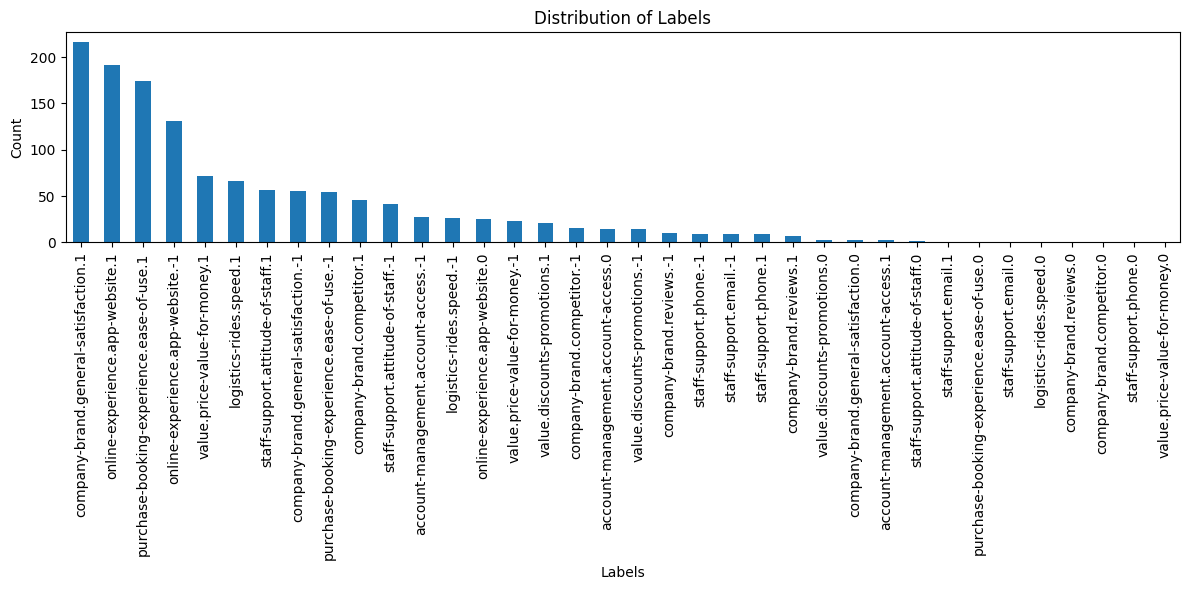

In [ ]:
train_subset10 = pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset10.csv', converters={'labels': ast.literal_eval})

# Apply the function to extract individual labels and store them in a list
all_labels = train_subset10['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of labels
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

20% Subsample

In [ ]:
# Convert 'labels' column to a format compatible with skmultilearn
label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
y = label_dummies.values
X = train_df.drop('labels', axis=1).values

# Use iterative stratification to get a subset
X_subset, y_subset, _, _ = iterative_train_test_split(X, y, test_size=0.80)

# Convert y_subset back to your original format
def get_original_labels(row, label_mapping):
    return [label_mapping[i] for i, x in enumerate(row) if x == 1]

label_mapping = label_dummies.columns
labels_subset = pd.DataFrame(y_subset).apply(lambda row: get_original_labels(row, label_mapping), axis=1)

# Check if all labels are present in the subset
missing_labels = set(label_mapping) - set(labels_subset.explode().unique())

# Add instances for missing labels
for missing_label in missing_labels:
    missing_label_index = label_dummies[label_dummies[missing_label] == 1].index[0]
    X_subset = np.vstack([X_subset, X[missing_label_index]])
    y_subset = np.vstack([y_subset, y[missing_label_index]])

    # Update labels_subset
    row_labels = get_original_labels(y[missing_label_index], label_mapping)
    labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)

# Create a DataFrame for the subset
train_subset = pd.DataFrame(X_subset, columns=train_df.columns.drop('labels'))
train_subset['labels'] = labels_subset

# Check the distribution of label combinations
combinations = Counter(str(combination) for row in get_combination_wise_output_matrix(y_subset, order=2) for combination in row)

train_subset.to_csv('/content/gdrive/My Drive/MSc Project/train_subset20.csv', index=False)

<ipython-input-11-71d3dd57c109>:2: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
<ipython-input-11-71d3dd57c109>:27: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)



Label Counts:
 company-brand.general-satisfaction.1          430
online-experience.app-website.1               379
purchase-booking-experience.ease-of-use.1     343
online-experience.app-website.-1              262
value.price-value-for-money.1                 143
logistics-rides.speed.1                       131
staff-support.attitude-of-staff.1             115
company-brand.general-satisfaction.-1         110
purchase-booking-experience.ease-of-use.-1    109
company-brand.competitor.1                     88
staff-support.attitude-of-staff.-1             82
account-management.account-access.-1           55
online-experience.app-website.0                50
logistics-rides.speed.-1                       49
value.price-value-for-money.-1                 45
value.discounts-promotions.1                   41
company-brand.competitor.-1                    30
value.discounts-promotions.-1                  30
account-management.account-access.0            29
company-brand.reviews.-1          

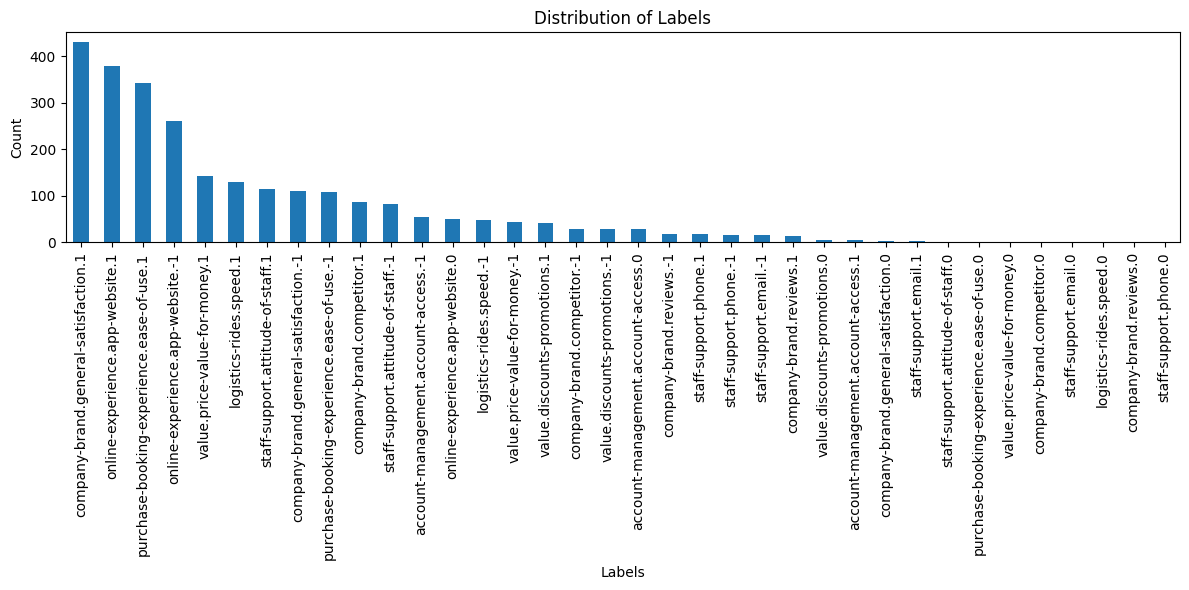

In [ ]:
train_subset20 = pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset20.csv', converters={'labels': ast.literal_eval})

# Apply the function to extract individual labels and store them in a list
all_labels = train_subset20['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of labels
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

30% Subsample

In [ ]:
# Convert 'labels' column to a format compatible with skmultilearn
label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
y = label_dummies.values
X = train_df.drop('labels', axis=1).values

# Use iterative stratification to get a subset
X_subset, y_subset, _, _ = iterative_train_test_split(X, y, test_size=0.70)

# Convert y_subset back to your original format
def get_original_labels(row, label_mapping):
    return [label_mapping[i] for i, x in enumerate(row) if x == 1]

label_mapping = label_dummies.columns
labels_subset = pd.DataFrame(y_subset).apply(lambda row: get_original_labels(row, label_mapping), axis=1)

# Check if all labels are present in the subset
missing_labels = set(label_mapping) - set(labels_subset.explode().unique())

# Add instances for missing labels
for missing_label in missing_labels:
    missing_label_index = label_dummies[label_dummies[missing_label] == 1].index[0]
    X_subset = np.vstack([X_subset, X[missing_label_index]])
    y_subset = np.vstack([y_subset, y[missing_label_index]])

    # Update labels_subset
    row_labels = get_original_labels(y[missing_label_index], label_mapping)
    labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)

# Create a DataFrame for the subset
train_subset = pd.DataFrame(X_subset, columns=train_df.columns.drop('labels'))
train_subset['labels'] = labels_subset

# Check the distribution of label combinations
combinations = Counter(str(combination) for row in get_combination_wise_output_matrix(y_subset, order=2) for combination in row)

train_subset.to_csv('/content/gdrive/My Drive/MSc Project/train_subset30.csv', index=False)

<ipython-input-12-aa655844de53>:2: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  label_dummies = pd.get_dummies(train_df['labels'].apply(pd.Series).stack()).sum(level=0)
<ipython-input-12-aa655844de53>:27: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  labels_subset = labels_subset.append(pd.Series([row_labels]), ignore_index=True)



Label Counts:
 company-brand.general-satisfaction.1          644
online-experience.app-website.1               569
purchase-booking-experience.ease-of-use.1     516
online-experience.app-website.-1              392
value.price-value-for-money.1                 211
logistics-rides.speed.1                       196
staff-support.attitude-of-staff.1             173
company-brand.general-satisfaction.-1         165
purchase-booking-experience.ease-of-use.-1    161
company-brand.competitor.1                    131
staff-support.attitude-of-staff.-1            122
account-management.account-access.-1           80
online-experience.app-website.0                75
logistics-rides.speed.-1                       72
value.price-value-for-money.-1                 68
value.discounts-promotions.1                   62
company-brand.competitor.-1                    45
value.discounts-promotions.-1                  45
account-management.account-access.0            44
staff-support.phone.-1            

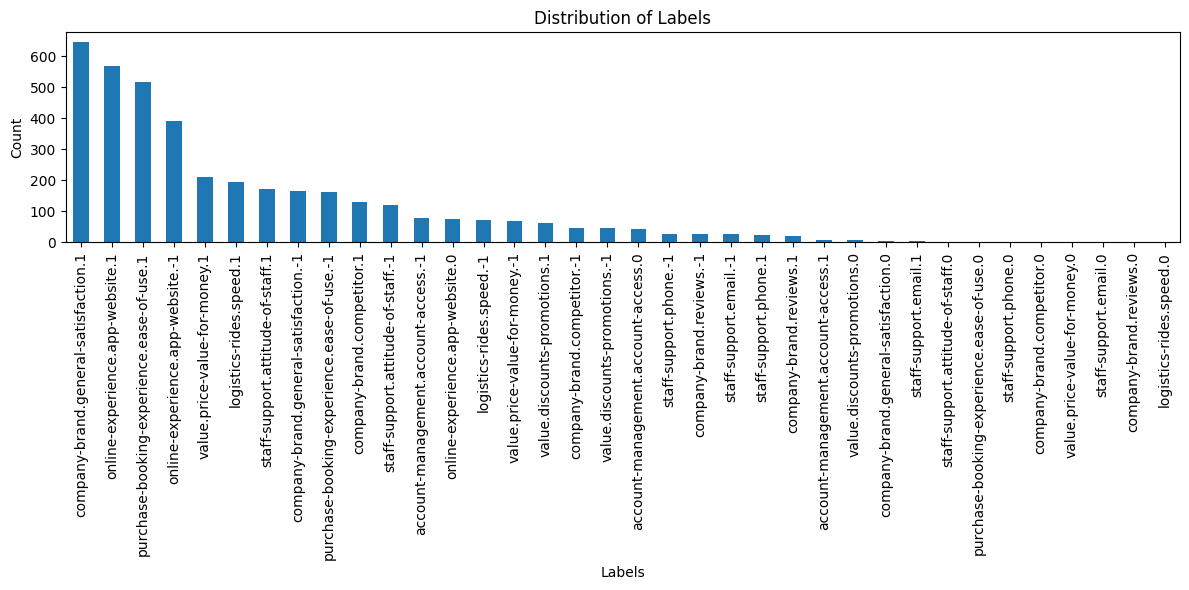

In [ ]:
train_subset30 = pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset30.csv', converters={'labels': ast.literal_eval})

# Apply the function to extract individual labels and store them in a list
all_labels = train_subset30['labels'].sum()

# Count the occurrences of each label
label_counts = pd.Series(all_labels).value_counts()

# Print the counts of labels
print("\nLabel Counts:\n", label_counts)

# Plot the distribution of labels
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()